<a href="https://colab.research.google.com/github/Alek-2321/Trabalho_Machine_Learning_F.Posser/blob/main/machine_learning_trabalho_F_Posser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Integração de Dados de Criminalidade e Meteorologia em Passo Fundo

Este projeto foi organizado em etapas para apresentar, de forma clara, o processo de coleta, tratamento, integração e análise dos dados de criminalidade e meteorologia do município de Passo Fundo.

Temos como objetivo analisar a possível influência de variáveis meteorológicas sobre a ocorrência de crimes no município de Passo Fundo. A partir da integração de dados de criminalidade com informações climáticas, busca-se identificar padrões, correlações e possíveis relações entre fatores como temperatura, umidade e precipitação e a variação nos índices criminais ao longo do tempo.


## Etapa 1 — Preparação do ambiente

Nesta etapa são importadas as bibliotecas utilizadas ao longo do projeto. O objetivo é deixar explícitos, desde o início, os recursos necessários para leitura, tratamento, visualização e normalização dos dados.


In [1]:
# Importa as bibliotecas utilizadas no projeto e ajusta algumas opções de exibição do pandas para facilitar a inspeção das tabelas.
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## Etapa 1.2 — Definição dos caminhos dos arquivos

Os caminhos da pasta principal e das subpastas de crimes e clima são configurados nesta etapa. Também são realizados testes simples para confirmar que os diretórios existem antes do início da leitura dos arquivos.


In [2]:
# Monta o Google Drive no ambiente do Colab para permitir o acesso aos arquivos armazenados na pasta do projeto.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Define a pasta principal do trabalho e cria os caminhos das subpastas que armazenam os arquivos de crimes e de clima.
import os
import pandas as pd

pasta_base = "/content/drive/MyDrive/TRABALHO_MACHINE_LEARNING"
pasta_crimes = os.path.join(pasta_base, "crimes")
pasta_clima = os.path.join(pasta_base, "clima")

In [4]:
# Verifica se os caminhos configurados realmente existem. Essa checagem evita erros de leitura e documenta que a estrutura de pastas foi validada.
print("Pasta base existe?", os.path.exists(pasta_base))
print("Pasta crimes existe?", os.path.exists(pasta_crimes))
print("Pasta clima existe?", os.path.exists(pasta_clima))

Pasta base existe? True
Pasta crimes existe? True
Pasta clima existe? True


## Etapa 1.3 — Busca e organização dos arquivos

Após a definição dos caminhos, os arquivos CSV são localizados e separados por tema:

- dados de criminalidade;
- dados meteorológicos.

Essa verificação é importante para demonstrar que a coleta foi conferida antes do processamento.


In [5]:
# Lista os arquivos CSV disponíveis em cada pasta e separa os conjuntos de dados de criminalidade e meteorologia.
arquivos_crime = sorted([
    os.path.join(pasta_crimes, arquivo)
    for arquivo in os.listdir(pasta_crimes)
    if arquivo.lower().endswith(".csv")
])

arquivos_clima = sorted([
    os.path.join(pasta_clima, arquivo)
    for arquivo in os.listdir(pasta_clima)
    if arquivo.lower().endswith(".csv")
])

print("Arquivos de crimes encontrados:")
for arq in arquivos_crime:
    print("-", arq)

print("\nArquivos de clima encontrados:")
for arq in arquivos_clima:
    print("-", arq)

if not arquivos_crime:
    raise FileNotFoundError("Nenhum arquivo CSV foi encontrado na pasta de crimes.")

if not arquivos_clima:
    raise FileNotFoundError("Nenhum arquivo CSV foi encontrado na pasta de clima.")

Arquivos de crimes encontrados:
- /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/crimes/SPJ_DADOS_ABERTOS_OCORRÊNCIAS_JAN_DEZ_2025 - Em 05.01.2026.csv

Arquivos de clima encontrados:
- /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/clima/PASSO FUNDO - dados_A839_D_2021-01-01_2025-09-05.csv


## Etapa 2 — Leitura e concatenação dos dados de criminalidade

Nesta etapa, os arquivos de criminalidade são lidos individualmente e reunidos em um único DataFrame. O procedimento garante a consolidação da base antes do início da limpeza e permite verificar se nenhum arquivo relevante ficou de fora.


In [6]:
# Lê todos os arquivos de criminalidade, padroniza os nomes das colunas, remove colunas totalmente vazias e concatena tudo em uma única base.
def ler_crimes(lista_arquivos):
    dfs = []

    for caminho in lista_arquivos:
        print(f"Lendo arquivo de crime: {os.path.basename(caminho)}")

        df = pd.read_csv(
            caminho,
            sep=";",
            encoding="latin1",
            low_memory=False
        )

        df.columns = df.columns.str.strip().str.lower()
        df = df.dropna(axis=1, how="all")

        dfs.append(df)

    df_crime = pd.concat(dfs, ignore_index=True)
    return df_crime


In [7]:
# Lê os arquivos meteorológicos, ignora as linhas iniciais de metadados, remove linhas e colunas vazias e consolida os dados em um único DataFrame.
def ler_clima(lista_arquivos):
    dfs = []

    for caminho in lista_arquivos:
        print(f"Lendo arquivo de clima: {os.path.basename(caminho)}")

        df = pd.read_csv(
            caminho,
            sep=";",
            encoding="latin1",
            skiprows=9,
            low_memory=False
        )

        df = df.dropna(axis=1, how="all")
        df = df.dropna(how="all")

        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

df_clima = ler_clima(arquivos_clima)

Lendo arquivo de clima: PASSO FUNDO - dados_A839_D_2021-01-01_2025-09-05.csv


In [8]:
# Executa a leitura das duas coleções de arquivos e apresenta a dimensão inicial das bases de crimes e clima.
df_crime = ler_crimes(arquivos_crime)
df_clima = ler_clima(arquivos_clima)

print("\nDimensão dos crimes:", df_crime.shape)
print("Dimensão do clima:", df_clima.shape)

Lendo arquivo de crime: SPJ_DADOS_ABERTOS_OCORRÊNCIAS_JAN_DEZ_2025 - Em 05.01.2026.csv
Lendo arquivo de clima: PASSO FUNDO - dados_A839_D_2021-01-01_2025-09-05.csv

Dimensão dos crimes: (763795, 181)
Dimensão do clima: (1709, 6)


## Etapa 3 — Limpeza e padronização dos dados de criminalidade

O tratamento aplicado à base de crimes contempla os seguintes pontos:

- padronização dos nomes das colunas;
- remoção de colunas completamente vazias;
- identificação e conversão da coluna de data;
- filtragem dos registros de Passo Fundo;
- tratamento de ausências em campos essenciais;
- remoção de duplicidades;
- padronização de valores categóricos, quando necessário.

Além da limpeza, esta etapa evidencia uma verificação importante do processo: inicialmente a coluna de data não estava no formato adequado para análise temporal, e por isso foi convertida para `datetime`.


In [9]:
# Aplica a limpeza da base de crimes: padroniza colunas, remove vazios e duplicidades, identifica a coluna de data, converte para datetime e filtra o município de Passo Fundo.
# Padronizar nomes das colunas
df_crime.columns = df_crime.columns.str.strip().str.lower()

# Remover colunas completamente vazias
df_crime = df_crime.dropna(axis=1, how="all")

# Remover duplicatas
df_crime = df_crime.drop_duplicates()

# Identificar coluna de data
colunas_data = [col for col in df_crime.columns if "data" in col]
print("Colunas de data encontradas:", colunas_data)

# Definir a coluna correta (ajuste se necessário)
coluna_data_crime = colunas_data[0]

# Converter para datetime
df_crime[coluna_data_crime] = pd.to_datetime(df_crime[coluna_data_crime], errors="coerce")

# Remover registros com data inválida
df_crime = df_crime.dropna(subset=[coluna_data_crime])

# Filtrar apenas Passo Fundo (ajuste nome da coluna se necessário)
colunas_cidade = [col for col in df_crime.columns if "municipio" in col or "cidade" in col]
print("Colunas de cidade encontradas:", colunas_cidade)

if colunas_cidade:
    coluna_cidade = colunas_cidade[0]
    df_crime = df_crime[df_crime[coluna_cidade].str.upper() == "PASSO FUNDO"]

# Padronizar colunas categóricas (opcional, mas recomendado)
colunas_categoricas = df_crime.select_dtypes(include="object").columns

for col in colunas_categoricas:
    df_crime[col] = df_crime[col].astype(str).str.strip().str.lower()

print("Dimensão final após limpeza:", df_crime.shape)

Colunas de data encontradas: ['data fato']
Colunas de cidade encontradas: ['municipio fato']
Dimensão final após limpeza: (6426, 181)


## Etapa 3.1 — Construção da base diária de criminalidade

Como os registros de ocorrência estão em nível individual e os dados meteorológicos estão organizados por dia, os crimes foram agregados por data. Assim, a base de criminalidade passou a representar a quantidade diária de ocorrências, tornando possível a integração posterior com o clima.


In [10]:
# Agrupa os registros criminais por data e cria a quantidade diária de crimes, preparando a base para a integração com os dados meteorológicos.
# Conferir colunas de data
colunas_data = [col for col in df_crime.columns if "data" in col]
print("Colunas de data encontradas:", colunas_data)

# Definir a coluna de data usada para agregação
coluna_data_crime = colunas_data[0]

# Agrupar quantidade de crimes por dia
df_crime_diario = (
    df_crime
    .groupby(coluna_data_crime)
    .size()
    .reset_index(name="qtd_crimes")
    .rename(columns={coluna_data_crime: "data"})
)

print("Dimensão da base diária de crimes:", df_crime_diario.shape)
display(df_crime_diario.head())

Colunas de data encontradas: ['data fato']
Dimensão da base diária de crimes: (144, 2)


,data,qtd_crimes
0,2025-01-01,44
1,2025-01-02,46
2,2025-01-03,60
3,2025-01-04,47
4,2025-01-05,54


## Etapa 4 — Limpeza e padronização do dataset meteorológico

Para a base meteorológica, o tratamento foi direcionado à padronização estrutural e numérica dos dados. Foram realizadas as seguintes ações:

- remoção de colunas e linhas completamente vazias;
- renomeação das colunas para nomes mais objetivos;
- conversão da coluna de data para `datetime`;
- substituição de vírgula por ponto em variáveis numéricas;
- conversão das colunas climáticas para formato numérico;
- remoção de registros com ausências em campos essenciais.

Esse processo garante compatibilidade com a base de criminalidade antes da integração.


In [11]:
# Padroniza a estrutura da base meteorológica, converte a data, trata vírgulas decimais, transforma as variáveis climáticas em numéricas e remove ausências essenciais.
df_clima.columns = [
    "data",
    "precipitacao",
    "temp_max",
    "temp_min",
    "umidade",
    "vento"
]

df_clima["data"] = pd.to_datetime(df_clima["data"], errors="coerce")

colunas_numericas_clima = ["precipitacao", "temp_max", "temp_min", "umidade", "vento"]

for col in colunas_numericas_clima:
    df_clima[col] = (
        df_clima[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df_clima[col] = pd.to_numeric(df_clima[col], errors="coerce")

df_clima = df_clima.dropna(subset=["data"])

print(df_clima.info())
display(df_clima.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1709 entries, 0 to 1708
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   data          1709 non-null   datetime64[ns]
 1   precipitacao  1644 non-null   float64       
 2   temp_max      1662 non-null   float64       
 3   temp_min      1660 non-null   float64       
 4   umidade       1677 non-null   float64       
 5   vento         1649 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 80.2 KB
None


,data,precipitacao,temp_max,temp_min,umidade,vento
0,2021-01-01,0.0,27.5,14.7,65.0,2.4
1,2021-01-02,0.0,28.4,16.3,55.8,3.8
2,2021-01-03,0.0,28.5,15.4,60.4,4.1
3,2021-01-04,0.0,28.8,15.6,67.6,4.4
4,2021-01-05,6.4,24.0,19.6,87.3,1.7


## Etapa 4.1 — Integração entre criminalidade e meteorologia

A integração foi realizada pela coluna de data, considerando a base de crimes já agregada por dia. O resultado é uma base unificada, contendo a quantidade diária de crimes e as variáveis meteorológicas correspondentes ao mesmo período.


In [12]:
# Realiza o merge entre a base diária de crimes e a base meteorológica utilizando a data como chave de integração.
df_final = pd.merge(df_crime_diario, df_clima, on="data", how="inner")

print("Dimensão da base integrada:", df_final.shape)
display(df_final.head())

Dimensão da base integrada: (101, 7)


,data,qtd_crimes,precipitacao,temp_max,temp_min,umidade,vento
0,2025-01-01,44,0.2,30.0,17.9,76.7,3.5
1,2025-01-02,46,14.0,28.8,17.3,81.5,2.5
2,2025-01-03,60,4.0,29.7,18.7,65.1,2.4
3,2025-01-04,47,0.0,25.9,14.9,50.2,2.0
4,2025-01-05,54,0.0,27.1,13.9,56.6,1.9


## Etapa 5 — Consolidação da base analítica por dia

Depois do merge, a base integrada passa por verificações finais de consistência, com foco em:

- remoção de duplicidades;
- eliminação de colunas totalmente vazias, se existirem;
- conferência de valores ausentes;
- manutenção apenas de registros com informações essenciais.

Essa etapa gera a base analítica final utilizada nas análises exploratórias.


In [13]:
# Faz as verificações finais da base integrada, removendo duplicidades, colunas totalmente vazias e linhas com ausência em variáveis essenciais.
# Remover duplicatas
df_final = df_final.drop_duplicates()

# Remover colunas completamente vazias, se houver
df_final = df_final.dropna(axis=1, how="all")

# Verificar valores ausentes
print("Valores ausentes por coluna:")
print(df_final.isna().sum())

# Opcional: remover linhas com ausências em colunas essenciais
colunas_essenciais = ["data", "qtd_crimes", "precipitacao", "temp_max", "temp_min", "umidade", "vento"]
df_final = df_final.dropna(subset=colunas_essenciais)

print("\nDimensão final após limpeza:", df_final.shape)
display(df_final.head())

Valores ausentes por coluna:
data             0
qtd_crimes       0
precipitacao    17
temp_max        16
temp_min        15
umidade          9
vento           18
dtype: int64

Dimensão final após limpeza: (83, 7)


,data,qtd_crimes,precipitacao,temp_max,temp_min,umidade,vento
0,2025-01-01,44,0.2,30.0,17.9,76.7,3.5
1,2025-01-02,46,14.0,28.8,17.3,81.5,2.5
2,2025-01-03,60,4.0,29.7,18.7,65.1,2.4
3,2025-01-04,47,0.0,25.9,14.9,50.2,2.0
4,2025-01-05,54,0.0,27.1,13.9,56.6,1.9


A compatibilização entre as bases exigiu a agregação dos crimes por data, pois os dados meteorológicos já estavam em granularidade diária. Após a integração, foram aplicadas verificações adicionais para garantir consistência, removendo duplicidades e ausências em campos essenciais da base final.


## Etapa 5.1 — Identificação de colunas vazias e análise de outliers

Nesta etapa, a atenção se volta à qualidade estatística da base final. Primeiro, garante-se que não existam colunas integralmente vazias. Em seguida, a variável `qtd_crimes` é analisada com o método do intervalo interquartil (IQR), permitindo identificar dias com comportamento muito distante do padrão observado.


In [14]:
# Calcula os limites do método IQR para identificar dias com quantidade de crimes muito acima ou abaixo do comportamento típico da série.
# Identificação de outliers na variável qtd_crimes

Q1 = df_final["qtd_crimes"].quantile(0.25)
Q3 = df_final["qtd_crimes"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_final[
    (df_final["qtd_crimes"] < limite_inferior) |
    (df_final["qtd_crimes"] > limite_superior)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)
print("Quantidade de outliers encontrados:", outliers.shape[0])

display(outliers.head())

Q1: 42.0
Q3: 51.0
IQR: 9.0
Limite inferior: 28.5
Limite superior: 64.5
Quantidade de outliers encontrados: 3


,data,qtd_crimes,precipitacao,temp_max,temp_min,umidade,vento
24,2025-03-01,28,10.4,32.9,20.5,79.6,3.0
49,2025-05-02,65,0.0,21.0,11.5,77.9,2.4
58,2025-05-11,65,0.0,19.3,8.6,68.3,1.9


Os outliers da variável `qtd_crimes` foram identificados com base no método do intervalo interquartil (IQR). O objetivo não foi eliminar automaticamente esses registros, mas destacar dias atípicos para avaliação. Em dados de segurança pública, valores extremos podem representar eventos reais e relevantes, e não necessariamente erros de entrada.


In [15]:
# Cria uma cópia da base final para análise, preservando os registros identificados como outliers.
# Manutenção da base original após análise dos outliers

df_analise = df_final.copy()

print("Dimensão da base mantida para análise:", df_analise.shape)

Dimensão da base mantida para análise: (83, 7)


Os registros classificados como outliers foram mantidos na base analítica. Essa decisão foi adotada porque valores extremos, neste contexto, podem refletir a dinâmica real da criminalidade e contribuir para a interpretação dos resultados.


## Etapa 5.2 — Normalização das variáveis numéricas

Com a base já tratada, as variáveis numéricas de interesse foram normalizadas por meio do método Min-Max. A padronização da escala favorece comparações entre variáveis e apoia análises posteriores.


In [16]:
# Aplica a normalização Min-Max nas variáveis numéricas selecionadas e gera a base preparada para comparações em mesma escala.
from sklearn.preprocessing import MinMaxScaler

df_modelo = df_analise.copy()

colunas_numericas = ["qtd_crimes", "precipitacao", "temp_max", "temp_min", "umidade", "vento"]

scaler = MinMaxScaler()
df_modelo[colunas_numericas] = scaler.fit_transform(df_modelo[colunas_numericas])

display(df_modelo.head())

,data,qtd_crimes,precipitacao,temp_max,temp_min,umidade,vento
0,2025-01-01,0.432432,0.005208,0.778261,0.829694,0.598194,0.575
1,2025-01-02,0.486486,0.364583,0.726087,0.803493,0.706546,0.325
2,2025-01-03,0.864865,0.104167,0.765217,0.864629,0.336343,0.300
3,2025-01-04,0.513514,0.000000,0.600000,0.698690,0.000000,0.200
4,2025-01-05,0.702703,0.000000,0.652174,0.655022,0.144470,0.175


As variáveis numéricas foram normalizadas para o intervalo entre 0 e 1. Esse procedimento não altera a relação entre os dados, mas facilita a comparação entre medidas que originalmente estavam em escalas diferentes.


## Etapa 6 — Exploração inicial dos dados

Nesta etapa são apresentados gráficos e medidas exploratórias que ajudam a observar padrões, dispersões e possíveis relações entre a criminalidade e as condições meteorológicas.


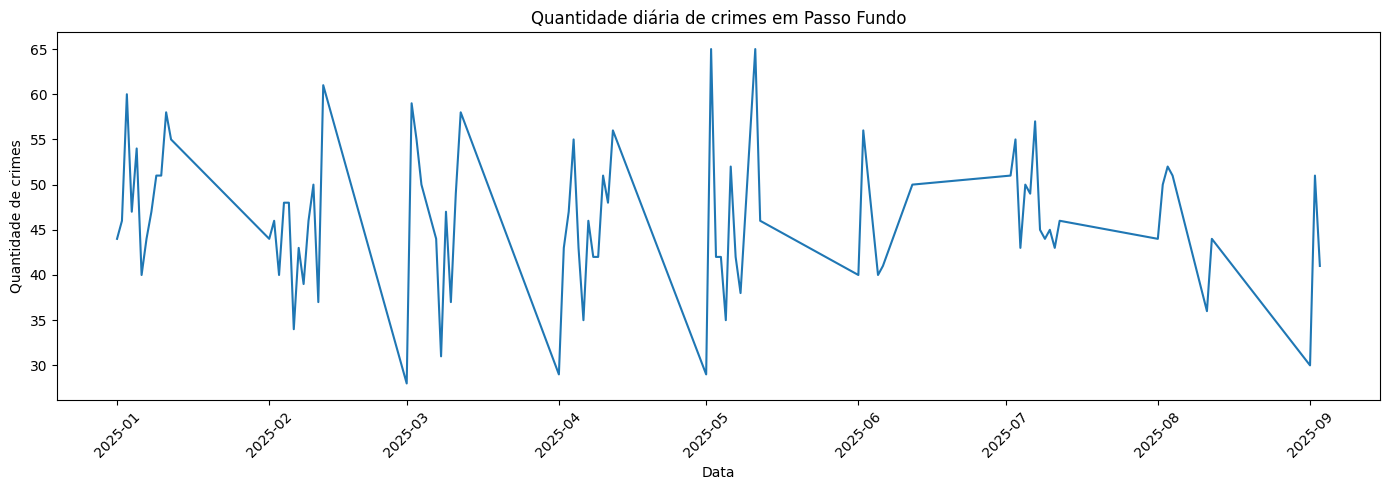

In [17]:
# Gera a série temporal da quantidade diária de crimes para visualizar a evolução das ocorrências ao longo do período analisado.
import matplotlib.pyplot as plt

# Série temporal da quantidade diária de crimes

plt.figure(figsize=(14, 5))
plt.plot(df_analise["data"], df_analise["qtd_crimes"])
plt.title("Quantidade diária de crimes em Passo Fundo")
plt.xlabel("Data")
plt.ylabel("Quantidade de crimes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A série temporal da quantidade diária de crimes revela oscilações ao longo do período analisado, com ocorrência de picos em datas específicas. Esse comportamento sugere a presença de variações pontuais na dinâmica das ocorrências, sem indicar, visualmente, uma tendência contínua de crescimento ou de queda em todo o intervalo observado.


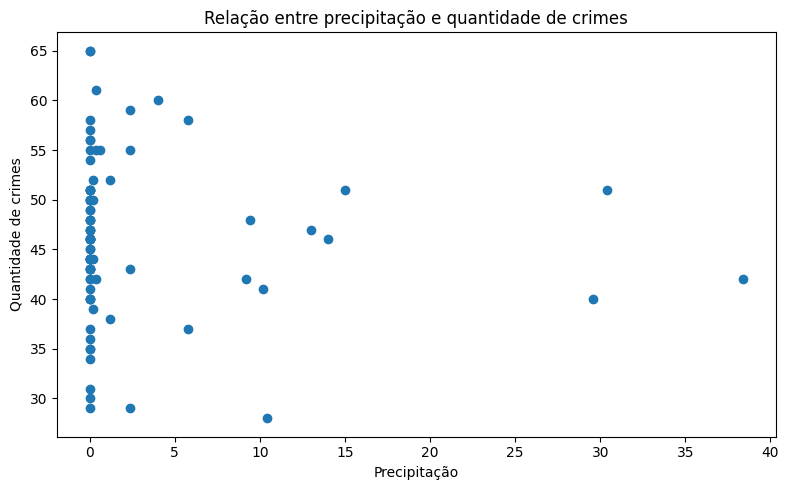

In [18]:
# Constrói o gráfico de dispersão entre precipitação e quantidade de crimes para observar possíveis associações entre chuva e ocorrências.
# Dispersão entre precipitação e quantidade de crimes

plt.figure(figsize=(8, 5))
plt.scatter(df_analise["precipitacao"], df_analise["qtd_crimes"])
plt.title("Relação entre precipitação e quantidade de crimes")
plt.xlabel("Precipitação")
plt.ylabel("Quantidade de crimes")
plt.tight_layout()
plt.show()

O gráfico de dispersão entre precipitação e quantidade de crimes sugere uma associação negativa fraca. Em termos visuais, os maiores volumes de ocorrências tendem a aparecer com mais frequência em dias de pouca ou nenhuma chuva. Ainda assim, a dispersão dos pontos indica que essa relação não é suficiente, por si só, para explicar a variação da criminalidade.


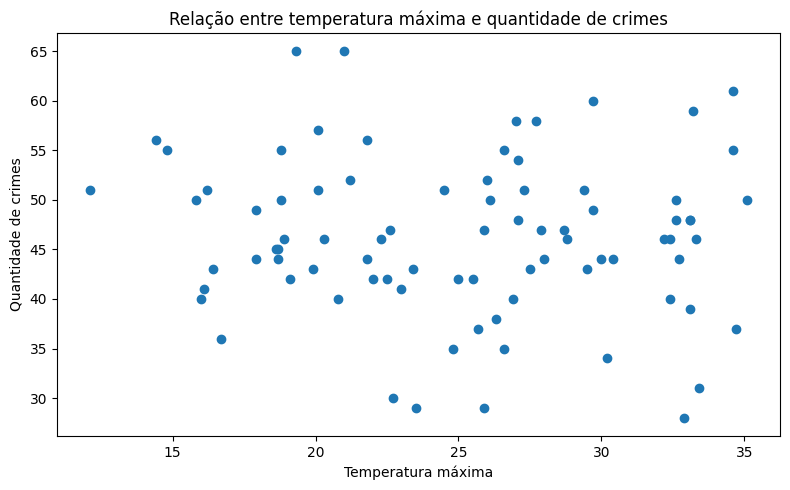

In [19]:
# Constrói o gráfico de dispersão entre temperatura máxima e quantidade de crimes para explorar a relação entre essas variáveis.
# Dispersão entre temperatura máxima e quantidade de crimes

plt.figure(figsize=(8, 5))
plt.scatter(df_analise["temp_max"], df_analise["qtd_crimes"])
plt.title("Relação entre temperatura máxima e quantidade de crimes")
plt.xlabel("Temperatura máxima")
plt.ylabel("Quantidade de crimes")
plt.tight_layout()
plt.show()

A relação entre temperatura máxima e quantidade de crimes apresenta alta dispersão e não evidencia um padrão linear forte. Os registros criminais se distribuem por diferentes faixas de temperatura, o que indica que essa variável, isoladamente, não explica de forma consistente a oscilação diária das ocorrências.


# 6.1  — Correlação entre variáveis

Selecionamos variáveis climáticas com maior potencial explicativo sobre comportamento humano.

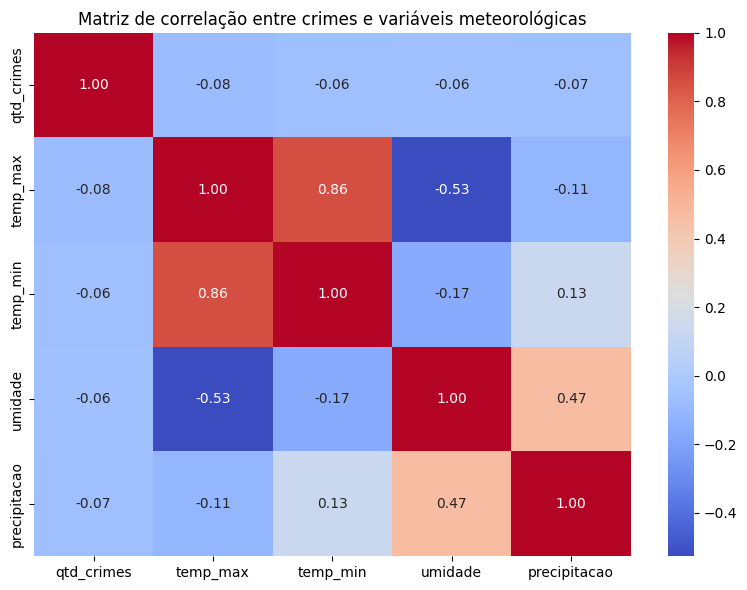

In [25]:
colunas_relevantes = [
    "qtd_crimes",
    "temp_max",
    "temp_min",
    "umidade",
    "precipitacao"
]

df_corr = df_final[colunas_relevantes].copy()


correlacoes = df_corr.corr()


plt.figure(figsize=(8, 6))
sns.heatmap(correlacoes, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlação entre crimes e variáveis meteorológicas")
plt.tight_layout()

A matriz de correlação indica que a quantidade de crimes possui correlação linear fraca com as variáveis meteorológicas analisadas. Em contrapartida, algumas relações esperadas entre variáveis climáticas aparecem com maior intensidade, como a associação entre precipitação e umidade e a relação positiva entre temperatura máxima e temperatura mínima.

De modo geral, os resultados sugerem que o comportamento da criminalidade não depende apenas do clima, sendo necessário considerar outros fatores para uma interpretação mais ampla do fenômeno.


## Etapa 7 — Exportação dos resultados

Ao final do processo, as principais bases podem ser exportadas para arquivo. Essa etapa facilita a entrega do dataset tratado e preserva, separadamente, a base integrada, a base analítica e a versão normalizada.


In [26]:
# Exporta as principais bases tratadas para arquivos CSV na pasta do projeto.
caminho_saida_final = os.path.join(pasta_base, 'base_integrada_final.csv')
caminho_saida_analise = os.path.join(pasta_base, 'base_analitica_diaria.csv')
caminho_saida_modelo = os.path.join(pasta_base, 'base_normalizada_modelo.csv')

df_final.to_csv(caminho_saida_final, index=False, encoding='utf-8-sig')
df_analise.to_csv(caminho_saida_analise, index=False, encoding='utf-8-sig')
df_modelo.to_csv(caminho_saida_modelo, index=False, encoding='utf-8-sig')

print('Arquivo exportado:', caminho_saida_final)
print('Arquivo exportado:', caminho_saida_analise)
print('Arquivo exportado:', caminho_saida_modelo)


Arquivo exportado: /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/base_integrada_final.csv
Arquivo exportado: /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/base_analitica_diaria.csv
Arquivo exportado: /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/base_normalizada_modelo.csv


- A base normalizada corresponde ao conjunto de dados de criminalidade após passar por etapas de limpeza e padronização, garantindo consistência, correção de tipos (como datas) e remoção de inconsistências.
- A base analítica diária, por sua vez, representa a agregação desses dados ao nível temporal, onde cada registro corresponde a um dia, permitindo a análise da quantidade de crimes ao longo do tempo.
- Base integrada final resulta da junção entre os dados de criminalidade e as informações meteorológicas, reunindo em um único arquivo todas as variáveis necessárias para análises mais avançadas, como correlações, visualizações e geração de insights.